## 1. 背景
我们现在有了一个经过标准化的单细胞测序数据，其保留了细胞差异，同时消除了技术带来的采样误差。通常来说，我们经过上游的mapping（比对），我们会得到30,000到50,000个不等的基因。但是，我们只在第一步的质控中，删除了一小部分基因（少于20个细胞表达的基因）。但实际上，一个细胞表达的基因大约是3,000个左右。意味着我们的测序数据中的一大部分基因可能不具有与单细胞数据相关的生物学意义，这些基因大多数包含0计数，或者是在许多细胞中普遍出现的基因。

故在预处理环节，我们需要计算高可变基因（特征基因），排除那些不具有分析意义的基因，避免影响我们下游的建模以及生物学检测。

In [ ]:
在本章中，我们将介绍三种不同的特征基因选择：

基于基因离散度，基于基因归一化方差以及基于基因的皮尔森残差。

在传统的分析流程中，我们会采用基于基因离散度的方式去计算高可变基因，一般来说，我们首先确定了单细胞数据集中变异最大的一组基因。

我们计算了所有单细胞中每个基因的平均值和离散度（方差/平均值），并根据基因的平均表达将其分为 20 个箱。

然后，在每个箱内，我们对箱内所有基因的离散度进行z归一化，以识别表达值高度可变的基因。



## 2. 基于基因离散度¶
我们首先设置我们的环境。

In [1]:
import omicverse as ov
import scanpy as sc

ov.ov_plot_set()

/home/zhen/miniforge3/envs/scanpy_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA GeForce RTX 3060 Laptop GPU
      Memory: 6.0 GB | Compute: 8.6

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.9   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [13]:
adata = sc.read(
    filename="s4d8_quality_control.h5ad",
    backup_url="https://ndownloader.figshare.com/files/40014331",
)

In [3]:
#存储原始数据以便后续还原
ov.utils.store_layers(adata,layers='counts')
adata.layers['counts']=adata.X.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata

......The X of adata have been stored in counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 14814 × 20171
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'layers_counts', 'log1p'
    layers: 'counts', 'soupX_counts'

接下来，我们调用scanpy包里的pp.highly_variable_genes函数来计算高可变基因，由于我们使用的是基于基因离散度的方法，故我们需要设置flavor='seurat'，该方法也是默认方法。基于基因离散度的方法寻找高变基因有两个途径：

指定目的高变基因数
指定离散度，平均值过滤高变基因
在这里，我们分别尝试两种不同的方法，首先是基于指定高变基因数的方法：



2.1 指定高可变基因数
由于是教程演示，所以我们不希望改变原来的anndata对象的.var，故我们设置inplace=False，旨在观察和对比高可变基因

In [4]:
adata_dis_num=sc.pp.highly_variable_genes(
    adata,
    flavor="seurat",
    n_top_genes=2000,
    subset=False,
    inplace=False,
)
adata_dis_num

extracting highly variable genes
    finished (0:00:00)


,means,dispersions,mean_bin,dispersions_norm,highly_variable
AL627309.1,0.000955,0.001085,"(-0.00329, 0.186]",-1.267316,False
AL627309.5,0.006057,0.715322,"(-0.00329, 0.186]",1.484390,True
LINC01409,0.036619,0.275313,"(-0.00329, 0.186]",-0.210809,False
LINC01128,0.022142,0.268974,"(-0.00329, 0.186]",-0.235233,False
LINC00115,0.002392,-0.093762,"(-0.00329, 0.186]",-1.632726,False
...,...,...,...,...,...
AC011043.1,0.003747,0.063567,"(-0.00329, 0.186]",-1.026594,False
AL354822.1,0.003144,0.307859,"(-0.00329, 0.186]",-0.085421,False
AL592183.1,0.062956,0.448886,"(-0.00329, 0.186]",0.457906,False
AC240274.1,0.012018,0.158723,"(-0.00329, 0.186]",-0.659990,False


In [5]:
adata_dis_num['highly_variable'].value_counts()

highly_variable
False    18171
True      2000
Name: count, dtype: int64

2.2 指定基因离散度与平均值阈值
除了指定高可变基因数量外，我们还可以通过基因的离散度与平均值的阈值，去计算高可变基因.

<div style="background-color: #5c8c03;">
但是，这种启发式的方法是数据敏感的，阈值所计算出来的高可变基因可能并不是全部高可变。

</div>


<div style="background-color: #ed00f5;">
故基于阈值的方法在现在的分析中应用较少 </div>

In [6]:
adata_dis_cutoff=sc.pp.highly_variable_genes(
    adata,
    flavor="seurat",
    min_disp=0.5,
    min_mean=0.0125,
    max_mean=3,
    subset=False,
    inplace=False,
)
adata_dis_cutoff['highly_variable'].value_counts()

extracting highly variable genes
    finished (0:00:00)


highly_variable
False    17291
True      2880
Name: count, dtype: int64

通过简单的计算我们发现，一共有2,880个高可变基因被选择了出来，一般2000-3000内的高可变基因数都是能接受的 



因为非高可变基因在下游分析时会被过滤掉，我们会将归一化值给保存进raw文件，但这有个缺陷，我们将会永远失去非高可变基因的原始count。因此可以使用释放函数 ov.utils.retrieve_layers，与存放在adata.layers中的数据不同，

<div style="background-color: #560c4e; padding: 10px;">
retrieve_layers函数还可还原全基因的原始计数，我们以下将进行一个简单的对比实验。
</div>

In [9]:
#计算高可变基因（覆盖，inplace=True）
 
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat",
)
adata.raw = adata.copy()  # 修改说明: 保存全基因数据到 raw，避免后续 raw 为空
#只保留高可变基因
adata = adata[:, adata.var.highly_variable]
print('shape: ',adata.shape)

adata_counts=adata.copy()
ov.utils.retrieve_layers(adata_counts,layers='counts')
print('normalize adata:',adata.X.max())
print('raw count adata:',adata_counts.X.max())
print('shape: ',adata_counts.shape)


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
shape:  (14814, 451)
......The X of adata have been stored in raw
......The layers counts of adata have been retreved
normalize adata: 4.9448869840604806
raw count adata: 694.0
shape:  (14814, 451)


In [10]:
#释放所有基因
adata_counts=adata.raw.to_adata().copy()
ov.utils.retrieve_layers(adata_counts,layers='counts')
print('normalize adata:',adata.X.max())
print('raw count adata:',adata_counts.X.max())
print('shape: ',adata_counts.shape)

......The X of adata have been stored in raw
......The layers counts of adata have been retreved
normalize adata: 4.9448869840604806
raw count adata: 694.0
shape:  (14814, 2880)


3. 基于基因归一化方差

过去研究发现，仅用对数归一化 + 离散度的方法难以解释单细胞 RNA-seq 的均值-方差关系，因此在 Seurat v3 中引入方差稳定变换，并基于未归一化的计数矩阵选择高可变基因。主要步骤如下：

1. 计算每个基因的平均值 $\overline{x_i}$ 与方差 $\sigma_i$，并分别对二者取 log。
2. 用二次多项式拟合方差与均值关系：

$$ \sigma(x) = a x^2 + b x + c $$

3. 用拟合得到的期望标准差 $\sigma(x_i)$ 进行 z 转换：

$$ z_{ij}= \frac {x_{ij}-\overline{x_i}} {\sigma (x_i)} $$

其中 $z_{ij}$ 是细胞 j 中基因 i 的标准化值，$x_{ij}$ 是原始值。为降低技术异常值影响，将 $z_{ij}$ 截断到最大值 $\sqrt{N}$（N 为细胞总数）。
4. 对每个基因计算所有细胞的 z 值方差并排序，选取高变基因。

在 `scanpy` 中可设定 `flavor="seurat_v3"`，并指定未归一化计数矩阵 `layer="counts"`，通常选择标准化方差最高的 2,000 个基因。

##### 修改说明: 插入“基于基因归一化方差”说明与公式

In [ ]:
adata = sc.read(
    filename="s4d8_quality_control.h5ad",
    backup_url="https://ndownloader.figshare.com/files/40014331",
)

In [14]:
adata_var_num=sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    layer='counts',
    n_top_genes=2000,
    subset=False,
    inplace=False,
)
adata_var_num['highly_variable'].value_counts()

extracting highly variable genes


highly_variable
False    18171
True      2000
Name: count, dtype: int64

4. 基于基因皮尔森近似残差

除了基于基因归一化残差以及离散度的方法外，我们还可以基于皮尔森近似残差的思想来计算高可变基因，你一定注意到了我们此前的归一化步骤中包含了皮尔森残差的方法，但是在这里，我们依然是使用原始计数来计算高可变基因，这是scanpy的实现原理所导致的，

<div style="color:yellow;">
即我们可以使用移位对数来获得标准化数据，同时使用皮尔森残差法来获得高可变基因
</div>



在不考虑零膨胀的情况下，没有生物学变异的UMI或计数数据的常见建模假设是：基因 g 在细胞 c 的计数 $X_{cg}$ 服从 Poisson 或负二项分布，期望为 $\mu_{cg}=n_c p_g$。

$$
\begin{array}{r}
X_{c g} \sim \text{Poisson}(\mu_{c g}) \ \text{or}\ \mathrm{NB}(\mu_{c g},\theta), \\
\mu_{c g} = n_c p_g .
\end{array}
$$

泊松模型的最大似然解可写为：

$$
\hat{\mu}_{c g} = \frac{\sum_j X_{c j} \cdot \sum_i X_{i g}}{\sum_{i j} X_{i j}}
$$

基于该期望，可得到皮尔森近似残差：

$$
Z_{c g} = \frac{X_{c g} - \hat{\mu}_{c g}}{\sqrt{\hat{\mu}_{c g} + \hat{\mu}_{c g}^2 / \theta}}
$$

其中 $\hat{\mu}_{c g} + \hat{\mu}_{c g}^2 / \theta$ 是 NB 的方差，$\theta \to \infty$ 时退化为 Poisson 情形。HVG 可以按基因的残差方差排序获得。

在 `scanpy` 中可用 `sc.experimental.pp.highly_variable_genes`，设置 `flavor=\"pearson_residuals\"` 且指定 `layer=\"counts\"`，以原始计数计算该方法。

###### 修改说明: 修正 LaTeX 反斜杠转义并插入“基于基因皮尔森近似残差”说明与公式


In [15]:
adata_pearson_num=sc.experimental.pp.highly_variable_genes(
    adata, 
    flavor="pearson_residuals",
    layer='counts',
    n_top_genes=2000,
    subset=False,
    inplace=False,
)
adata_pearson_num['highly_variable'].value_counts()

extracting highly variable genes


highly_variable
False    18171
True      2000
Name: count, dtype: int64

In [16]:
adata_dis_num

,means,dispersions,mean_bin,dispersions_norm,highly_variable
AL627309.1,0.000955,0.001085,"(-0.00329, 0.186]",-1.267316,False
AL627309.5,0.006057,0.715322,"(-0.00329, 0.186]",1.484390,True
LINC01409,0.036619,0.275313,"(-0.00329, 0.186]",-0.210809,False
LINC01128,0.022142,0.268974,"(-0.00329, 0.186]",-0.235233,False
LINC00115,0.002392,-0.093762,"(-0.00329, 0.186]",-1.632726,False
...,...,...,...,...,...
AC011043.1,0.003747,0.063567,"(-0.00329, 0.186]",-1.026594,False
AL354822.1,0.003144,0.307859,"(-0.00329, 0.186]",-0.085421,False
AL592183.1,0.062956,0.448886,"(-0.00329, 0.186]",0.457906,False
AC240274.1,0.012018,0.158723,"(-0.00329, 0.186]",-0.659990,False


现在，我们已经获得了3种不同的特征基因选择方法所得到的高可变基因，
我们可以对比一下基因之间的重叠率，至于功能的研究则不在本章的考虑范围内。
我们先将基因名赋予此前的结果

In [ ]:
# adata = sc.read(
#     filename="s4d8_quality_control.h5ad",
#     backup_url="https://ndownloader.figshare.com/files/40014331",
# )

In [17]:
adata_dis_num.index=adata.var_names.copy()
adata_dis_cutoff.index=adata.var_names.copy()
adata_var_num.index=adata.var_names.copy()
adata_pearson_num.index=adata.var_names.copy()

In [19]:
# 修改说明: 在 notebook 内安装缺失依赖
import sys
!{sys.executable} -m pip install matplotlib-venn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=408f14fdda0c665ca1e0f53a6fa34cd3f15b47c355c094b807146f0cc7f45907
  Stored in directory: /home/zhen/.cache/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib-venn


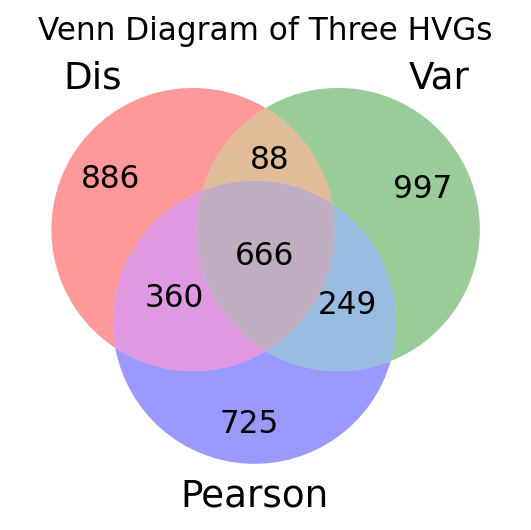

In [20]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# 三个列表的元素
list1 = set(adata_dis_num.loc[adata_dis_num['highly_variable']==True].index.tolist())
list2 = set(adata_var_num.loc[adata_var_num['highly_variable']==True].index.tolist())
list3 = set(adata_pearson_num.loc[adata_pearson_num['highly_variable']==True].index.tolist())

# 绘制 Venn 图
venn = venn3([list1, list2, list3], set_labels=('Dis', 'Var', 'Pearson'))


# 显示图形
plt.title("Venn Diagram of Three HVGs")
plt.show()


有意思的事情出现了，我们发现三种不同方法所找到的高可变基因（HVGs）仅有656个是相同的，这意味着不同的方法所寻找到的高可变基因可能会影响你的下游分析的误差。

<div style="color:yellow">
在我们的分析中，我们推荐使用皮尔森残差法来获得高可变基因。
</div>


在omicverse中，我们可以直接使用ov.pp.preprocess完成预处理步骤，

需要注意的是，当omicverse的版本小于1.4.13时，mode的参数只能设置为scanpy或pearson，


而在更高的版本中，normalize|HVGs：我们使用 | 来控制预处理步骤，| 前用于归一化步骤，可以是 shiftlog 或 pearson，| 后用于高度可变基因计算步骤，可以是 pearson 或 seurat。我们的默认值是 shiftlog|pearson。

In [21]:
adata = sc.read(
    filename="s4d8_quality_control.h5ad",
    #backup_url="https://figshare.com/ndownloader/files/40014331",
)
#存储原始数据以便后续还原
ov.utils.store_layers(adata,layers='counts')
adata.layers['counts']=adata.X.copy()

adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,)
adata

......The X of adata have been stored in counts
🔍 [2026-03-11 23:18:00] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 20171/20171 genes are kept.
    Among 20171 genes, 20171 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 14,814 cells × 20,171 genes
   ✓ Runtime: 9.05s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 20,171 total (9.9%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Bool

AnnData object with n_obs × n_vars = 14814 × 20171
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'layers_counts', 'history_log', 'log1p', 'hvg', 'status', 'status_args', 'REFERENCE_MANU'
    layers: 'counts', 'soupX_counts'


注意，与scanpy不同，omicverse计算高可变基因后，将保存为var['highly_variable_features']，

而在scanpy中，高可变将保存为var['highly_variable']

In [22]:
adata.var.head()

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,...,log1p_total_counts,n_cells,percent_cells,robust,highly_variable_features,means,variances,residual_variances,highly_variable_rank,highly_variable
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,False,False,False,30,0.001831,0.001829,99.822842,...,3.465736,27,0.182260,True,False,0.001823,0.001819,0.783158,NaN,False
AL627309.5,ENSG00000241860,Gene Expression,GRCh38,False,False,False,146,0.008976,0.008936,99.137829,...,5.030438,132,0.891049,True,False,0.008775,0.009239,1.063730,NaN,False
LINC01409,ENSG00000237491,Gene Expression,GRCh38,False,False,False,883,0.063009,0.061104,94.785638,...,6.973543,820,5.535304,True,False,0.061158,0.082670,1.080966,NaN,False
LINC01128,ENSG00000228794,Gene Expression,GRCh38,False,False,False,533,0.036140,0.035503,96.852486,...,6.418365,464,3.132172,True,False,0.033617,0.042615,1.162746,NaN,False
LINC00115,ENSG00000225880,Gene Expression,GRCh38,False,False,False,72,0.004370,0.004360,99.574820,...,4.317488,66,0.445525,True,False,0.004388,0.004504,0.834976,NaN,False


In [23]:
adata.write_h5ad('s4d8_preprocess.h5ad')